# GSE250346 (Dataset 01) — load & explore TMA5 SpatialData

GEO human lung Xenium TMA data ([GSE250346](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE250346)).

This notebook loads the companion **TMA5.zarr** SpatialData store and inspects its elements (images, labels, shapes, transcript points, cell table). For AnnData/h5ad exploration see [`00_load_and_explore.ipynb`](00_load_and_explore.ipynb).

> **Note:** `TMA5.zarr` uses Zarr v3 (SpatialData 0.7.2). Requires Python ≥3.11 and spatialdata ≥0.7.2.

**Kernel:** `spatialdata`

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import spatialdata as sd
import spatialdata_plot  # registers .pl accessor


ZARR_PATH = "/mnt/scratch2/Maycon/Hackathon/SJ_BioHack_2026/KIDS26-Team18/data/Dataset_01/raw_data/TMA5.zarr"
H5AD_PATH = "/mnt/scratch2/Maycon/Hackathon/SJ_BioHack_2026/KIDS26-Team18/data/Dataset_01/processed_data/outdated/GSE250346_slim.h5ad"

assert ZARR_PATH.is_dir(), f"Missing zarr store: {ZARR_PATH}"
assert H5AD_PATH.is_file(), f"Missing h5ad: {H5AD_PATH}"
print(f"Zarr path: {ZARR_PATH}")
print(f"h5ad path: {H5AD_PATH}")

Zarr path: /mnt/scratch2/Maycon/Hackathon/SJ_BioHack_2026/KIDS26-Team18/data/Dataset_01/processed_data/TMA5.zarr
h5ad path: /mnt/scratch2/Maycon/Hackathon/SJ_BioHack_2026/KIDS26-Team18/data/Dataset_01/processed_data/GSE250346_slim.h5ad


In [19]:
sdata = sd.read_zarr(ZARR_PATH)
print(sdata)

SpatialData object, with associated Zarr store: /mnt/scratch2/Maycon/Hackathon/SJ_BioHack_2026/KIDS26-Team18/data/Dataset_01/processed_data/TMA5.zarr
├── Images
│     └── 'morphology_focus': DataTree[cyx] (4, 91812, 54047), (4, 45906, 27023), (4, 22953, 13511), (4, 11476, 6755), (4, 5738, 3377)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (91812, 54047), (45906, 27023), (22953, 13511), (11476, 6755), (5738, 3377)
│     └── 'nucleus_labels': DataTree[yx] (91812, 54047), (45906, 27023), (22953, 13511), (11476, 6755), (5738, 3377)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 11) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (628860, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (628860, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (619670, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (628860, 343)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), cel

In [20]:
print("Images:", list(sdata.images.keys()))
morph = sdata.images["morphology_focus"]
print("  morphology_focus scales:", list(morph.children.keys()))
for scale in ["scale0", "scale4"]:
    ds = morph[scale].dataset
    print(f"    {scale}: {dict(ds.sizes)}")

print("\nLabels:", list(sdata.labels.keys()))
for key in sdata.labels:
    print(f"  {key} scales:", list(sdata.labels[key].children.keys()))

print("\nShapes:", list(sdata.shapes.keys()))
for key in sdata.shapes:
    print(f"  {key}: {len(sdata.shapes[key]):,} geometries")

print("\nPoints:", list(sdata.points.keys()))
transcripts = sdata.points["transcripts"]
print(f"  transcripts: {len(transcripts):,} rows, columns: {list(transcripts.columns)}")

print("\nTables:", list(sdata.tables.keys()))

Images: ['morphology_focus']
  morphology_focus scales: ['scale0', 'scale1', 'scale2', 'scale3', 'scale4']
    scale0: {'c': 4, 'y': 91812, 'x': 54047}
    scale4: {'c': 4, 'y': 5738, 'x': 3377}

Labels: ['cell_labels', 'nucleus_labels']
  cell_labels scales: ['scale0', 'scale1', 'scale2', 'scale3', 'scale4']
  nucleus_labels scales: ['scale0', 'scale1', 'scale2', 'scale3', 'scale4']

Shapes: ['cell_boundaries', 'cell_circles', 'nucleus_boundaries']
  cell_boundaries: 628,860 geometries
  cell_circles: 628,860 geometries
  nucleus_boundaries: 619,670 geometries

Points: ['transcripts']
  transcripts: 120,801,715 rows, columns: ['x', 'y', 'z', 'feature_name', 'cell_id', 'codeword_index', 'fov_name', 'nucleus_distance', 'qv', 'transcript_id', 'overlaps_nucleus']

Tables: ['table']


In [21]:
table = sdata.tables["table"]
print(table)
print(f"\nobs columns ({len(table.obs.columns)}): {table.obs.columns.tolist()}")
print(f"obsm keys: {list(table.obsm.keys())}")
table.obs.head()

AnnData object with n_obs × n_vars = 628860 × 343
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'z_level', 'nucleus_count', 'cell_labels'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

obs columns (13): ['cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'z_level', 'nucleus_count', 'cell_labels']
obsm keys: ['spatial']


,cell_id,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,region,z_level,nucleus_count,cell_labels
cell_id,,,,,,,,,,,,,
aaaacegf-1,aaaacegf-1,159,0,0,0,0,159,77.894534,27.906564,cell_circles,0.0,1.0,1
aaaadbii-1,aaaadbii-1,105,0,0,0,0,105,94.557191,18.739844,cell_circles,0.0,1.0,2
aaaadjlg-1,aaaadjlg-1,132,0,0,0,0,132,117.270786,32.422189,cell_circles,0.0,1.0,3
aaaafbfk-1,aaaafbfk-1,49,0,0,0,0,49,32.783439,18.288282,cell_circles,0.0,1.0,4
aaaafgpe-1,aaaafgpe-1,130,0,0,0,0,130,48.994533,27.048595,cell_circles,0.0,1.0,5


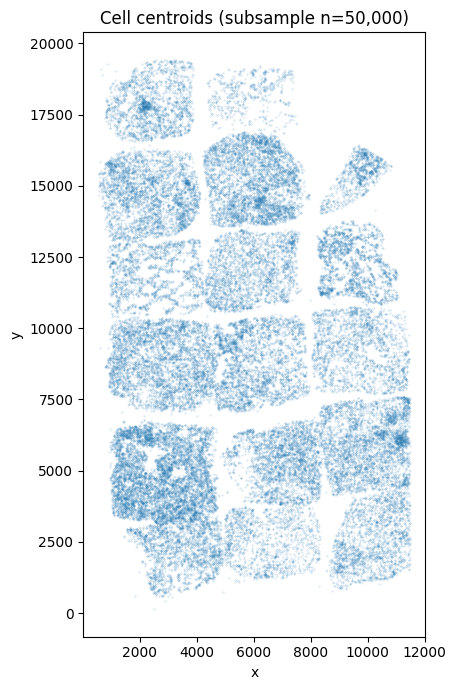

In [22]:
# Centroid scatter (subsample for speed)
coords = table.obsm["spatial"]
rng = np.random.default_rng(0)
n_sub = min(50_000, coords.shape[0])
idx = rng.choice(coords.shape[0], size=n_sub, replace=False)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(coords[idx, 0], coords[idx, 1], s=0.1, alpha=0.3, rasterized=True)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"Cell centroids (subsample n={n_sub:,})")
plt.tight_layout()
plt.show()

Cells in crop: 27,791


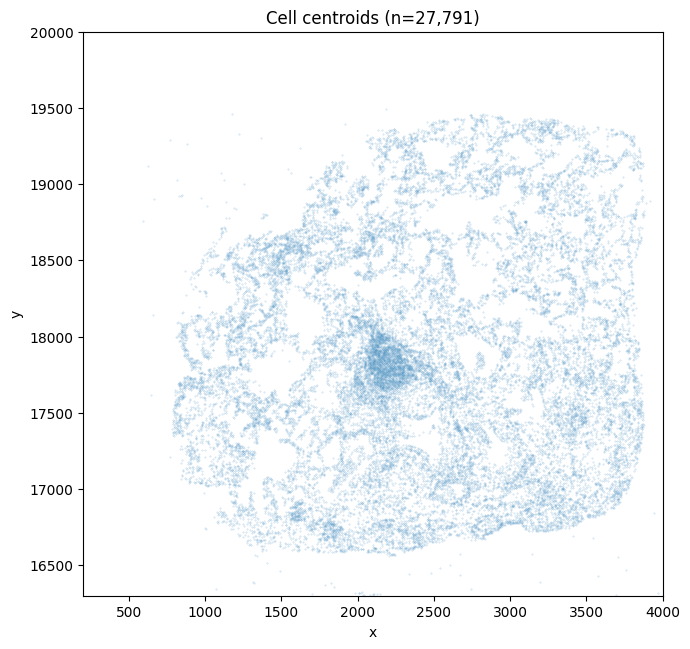

In [23]:
# Crop coordinates to bounding box
xmin = 200
xmax = 4000
ymin = 16300
ymax = 20000

coords = table.obsm["spatial"]

mask = (

    (coords[:, 0] >= xmin) &

    (coords[:, 0] <= xmax) &

    (coords[:, 1] >= ymin) &

    (coords[:, 1] <= ymax)

)

# Final cropped AnnData

adata = table[mask].copy()

print(f"Cells in crop: {adata.n_obs:,}")

# Plot centroids

coords = adata.obsm["spatial"]

fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(

    coords[:, 0],

    coords[:, 1],

    s=0.1,

    alpha=0.3,

    rasterized=True,

)

ax.set_aspect("equal")

ax.set_xlim(xmin, xmax)

ax.set_ylim(ymin, ymax)

ax.set_xlabel("x")

ax.set_ylabel("y")

ax.set_title(f"Cell centroids (n={adata.n_obs:,})")

plt.tight_layout()

plt.show()

## Cross-reference with h5ad

The cropped `adata` above is joined to `GSE250346_slim.h5ad` on `cell_id`, bringing in all h5ad `.obs` columns (e.g. `sample_id`, `final_CT`, `TMA_core`, UMAP). The full h5ad has 1,630,319 cells; the zarr table has 628,860 (TMA5 core only). See [`01_load_and_explore.ipynb`](01_load_and_explore.ipynb) for full h5ad exploration.

In [24]:
# Join all h5ad .obs columns onto the cropped SpatialData table (by cell_id)
adata_ref = sc.read_h5ad(H5AD_PATH, backed="r")
h5ad_obs = adata_ref.obs.drop_duplicates(subset="cell_id", keep="first").copy()

obs_sdata = adata.obs.copy()
if obs_sdata.index.name == "cell_id":
    obs_sdata = obs_sdata.reset_index(drop=True)

h5ad_cols = [c for c in h5ad_obs.columns if c != "cell_id"]
adata.obs = obs_sdata.merge(h5ad_obs[["cell_id", *h5ad_cols]], on="cell_id", how="left")

n_matched = adata.obs["sample_id"].notna().sum()
print(f"Merged h5ad obs: {len(h5ad_cols)} columns added")
print(f"Matched cells: {n_matched:,} / {adata.n_obs:,}")
print(f"Total obs columns: {len(adata.obs.columns)}")
print(adata.obs.columns.tolist())

/mnt/scratch1/miniconda3/envs/spatialdata/lib/python3.12/site-packages/anndata/_core/anndata.py:1878: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Merged h5ad obs: 30 columns added
Matched cells: 24,825 / 27,791
Total obs columns: 43
['cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'z_level', 'nucleus_count', 'cell_labels', 'sample_id', 'donor_id', 'full_cell_id', 'sample_type', 'sample_affect', 'disease_status', 'percent_pathology', 'TMA_core', 'run', 'final_CT', 'final_lineage', 'CNiche', 'TNiche', 'lumen_id', 'lumen_rank', 'coord_x', 'coord_y', 'adj_x_centroid', 'adj_y_centroid', 'super_adj_x_centroid', 'super_adj_y_centroid', 'nCount_RNA', 'nFeature_RNA', 'perc_negcontrolprobe', 'perc_negcontrolcodeword', 'perc_unassigned', 'perc_negcontrolorunassigned', 'UMAP1', 'UMAP2', 'cell_id_to_sdata']


/mnt/scratch1/miniconda3/envs/spatialdata/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [27]:
adata.obs = adata.obs.drop(columns=["UMAP1", "UMAP2"])

In [33]:
adata.obs["final_CT"].value_counts(dropna=False)

final_CT
Alveolar FBs                   3969
NaN                            2966
Venous                         2798
Capillary                      2121
SMCs/Pericytes                 1792
Interstitial Macrophages       1622
CD4+ T-cells                   1318
AT2                            1265
B cells                        1228
Inflammatory FBs               1154
Alveolar Macrophages            989
Mast                            863
CD8+ T-cells                    766
Monocytes/MDMs                  718
Neutrophils                     683
Activated Fibrotic FBs          575
AT1                             561
Plasma                          332
Lymphatic                       250
Basal                           236
NK/NKT                          218
RASC                            171
Transitional AT2                171
SPP1+ Macrophages               152
Tregs                           151
cDCs                            135
Proliferating FBs               108
KRT5-/KRT17+       

In [36]:
adata.obs.rename(
    columns={
        "transcript_counts": "nCount",
        "total_counts": "nFeature"
    },
    inplace=True
)

In [38]:
# Sanity check: .X should hold integer transcript counts
x = adata.X.toarray() if hasattr(adata.X, "toarray") else np.asarray(adata.X)
assert x.min() >= 0, f"Expected nonnegative counts, got min={x.min()}"
assert np.allclose(x.sum(axis=1), adata.obs["nCount"], rtol=1e-4), "X row sums must match nCount"
print(f"X holds integer transcript counts (min={x.min():.0f}, max={x.max():.0f})")
print(f"Row-sum check vs nCount: OK ({adata.n_obs:,} cells)")

X holds integer transcript counts (min=0, max=178)
Row-sum check vs nCount: OK (27,791 cells)


In [39]:
print("Published final_CT counts in this sample:")
display(adata.obs["final_CT"].value_counts().head(15))

Published final_CT counts in this sample:


final_CT
Alveolar FBs                3969
Venous                      2798
Capillary                   2121
SMCs/Pericytes              1792
Interstitial Macrophages    1622
CD4+ T-cells                1318
AT2                         1265
B cells                     1228
Inflammatory FBs            1154
Alveolar Macrophages         989
Mast                         863
CD8+ T-cells                 766
Monocytes/MDMs               718
Neutrophils                  683
Activated Fibrotic FBs       575
Name: count, dtype: int64

In [ ]:
adata.obs["sample_id"].value_counts(dropna=False)


sample_id
TILD028LA      24813
NaN             2966
TILD315MA         12
TILD049MA          0
THD0011            0
THD0008            0
TILD113LA          0
TILD117LA          0
TILD117MA1         0
TILD117MA2         0
TILD130LA          0
TILD167LA          0
TILD080LA          0
TILD111LA          0
TILD299MA          0
TILD175MA          0
VUHD049            0
VUHD038            0
VUHD090            0
VUHD095            0
VUHD113            0
VUHD069            0
VUHD116B           0
VUILD48LA1         0
VUILD48LA2         0
VUILD49LA          0
VUILD58MA          0
VUILD78LA          0
VUILD78MA          0
VUHD116A           0
VUILD91LA          0
VUILD91MA          0
VUILD96MA          0
VUILD96LA          0
VUILD102MA         0
VUILD104MA1        0
VUILD104MA2        0
VUILD102LA         0
VUILD105MA1        0
VUILD105MA2        0
VUILD107MA         0
VUILD106MA         0
VUILD110LA         0
VUILD115MA         0
VUILD141MA         0
VUILD142MA         0
Name: count, dtype: int6

In [ ]:
# adata.write_h5ad("/mnt/scratch2/Maycon/Hackathon/SJ_BioHack_2026/KIDS26-Team18/data/Dataset_01/processed_data/one_sample.h5ad")